# Raw data: HEALPix vs lat/lon grid

Loads the **same timestep** from both the HEALPix and native lat/lon pipelines (no model involved),
reprojects the HP pixels nearest-neighbour back to the lat/lon grid, and shows them side-by-side.

**Layout:** 10 rows (one per timestep) × 2 columns (HP | no-HP).  
Shared colour scale across all timesteps and both columns.

Edit the **Config** cell to change the variable, scenario, climate model, or timesteps.

In [1]:
import sys
sys.path.insert(0, "/home/x_tagty/equivariant-posteriors")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import healpix

from experiments.climate.data.climateset_data_hp import ClimatesetDataHP, ClimatesetHPConfig
from experiments.climate.data.climateset_data_no_hp import ClimatesetData, ClimatesetConfig

[Compute environment] paths: 
[Paths] checkpoints: /proj/heal_pangu/eqp_climate/checkpoints (/proj/heal_pangu/eqp_climate/checkpoints)
[Paths] locks: locks (/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/locks)
[Paths] distributed_requests: distributed_requests (/home/x_tagty/equivariant-posteriors/experiments/climate/notebooks/distributed_requests)
[Paths] artifacts: /proj/heal_pangu/eqp_climate/artifacts (/proj/heal_pangu/eqp_climate/artifacts)
[Paths] datasets: /proj/heal_pangu/users/x_tagty/climateset (/proj/heal_pangu/users/x_tagty/climateset)
[Compute environment] envs: None


/home/x_tagty/equivariant-posteriors/.venv/lib64/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Config

Edit this cell to change what is plotted.  Re-run all cells after changing.

In [8]:
# ── Variable ──────────────────────────────────────────────────────────────
# Output vars: "tas" (temperature) | "pr" (precipitation)
# Input  vars: "BC" | "CH4" | "SO2" | "CO2"
VAR_NAME  = "pr"

# ── Display ───────────────────────────────────────────────────────────────
LOG_SCALE = False    # True → log/symlog colourmaps (recommended for pr)
CMAP      = "RdBu_r" # try "viridis" for precip

# ── Climate model & ensemble ──────────────────────────────────────────────
CLIMATE_MODEL = "CAS-ESM2-0"
ENSEMBLE      = "r3i1p1f1"

# ── HEALPix resolution ────────────────────────────────────────────────────
NSIDE = 32

# ── 10 timesteps to compare  (year, month 1–12) ───────────────────────────
# ssp245 runs 2015–2100; adjust years freely within that range.
TIMESTEPS = [
    (2020, 1),
    (2025, 7),
    (2030, 1),
    (2040, 7),
    (2050, 1),
    (2060, 7),
    (2070, 1),
    (2080, 7),
    (2090, 1),
    (2100, 7),
]

## Load datasets

Both datasets load the **ssp245 scenario, 2015–2100**, raw (un-normalized).  
On first run the data is read from netCDF files and cached; subsequent runs load the cache (~seconds).

In [9]:
INPUT_VARS  = ["BC", "CH4", "SO2", "CO2"]
OUTPUT_VARS = ["tas", "pr"]
# CAS-ESM2-0 is not in the special fire-type mapping → defaults to "anthro-fires"
FIRE_TYPE   = "anthro-fires"

BASE = dict(
    climate_model = CLIMATE_MODEL,
    ensemble      = ENSEMBLE,
    input_vars    = INPUT_VARS,
    output_vars   = OUTPUT_VARS,
    scenarios     = ["ssp245"],
    years         = "2015-2100",
    fire_type     = FIRE_TYPE,
    seq_len       = 1,
    normalized    = False,
    split         = "all",
    cache         = True,
    spatial_res   = "250_km",
    temporal_res  = "mon",
)

print("Building configs ...")
hp_cfg   = ClimatesetHPConfig(nside=NSIDE, **BASE)
nohp_cfg = ClimatesetConfig(**BASE)

print("\nLoading HP dataset ...")
hp_ds = ClimatesetDataHP(hp_cfg)
print(f"  {len(hp_ds)} timesteps  |  input {hp_ds.input_data.shape}  |  output {hp_ds.output_data.shape}")

print("\nLoading no-HP dataset ...")
nohp_ds = ClimatesetData(nohp_cfg)
print(f"  {len(nohp_ds)} timesteps  |  input {nohp_ds.input_data.shape}  |  output {nohp_ds.output_data.shape}")

# Latitude/longitude grid for reprojection and display
nohp_lats = nohp_ds.lats
if nohp_lats is None:
    # Fallback: uniform grid matching standard 96-lat ClimateSet resolution
    nohp_lats = np.linspace(-90, 90, 96, endpoint=False) + (180 / 96 / 2)
    print("  WARNING: lats not found in cache — using synthetic uniform grid")

n_lat     = len(nohp_lats)
n_lon     = nohp_ds.output_data.shape[-1]   # typically 144
nohp_lons = np.linspace(0, 360, n_lon, endpoint=False)
print(f"  Grid: {n_lat} lats × {n_lon} lons")

Building configs ...

Loading HP dataset ...
Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_nside32_BC_CH4_SO2_CO2_ssp245_2015-2100_nohistoric_anthro-fires
  Loaded INPUT from cache: shape=(1032, 4, 12288)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_CAS-ESM2-0_r3i1p1f1_nside32_tas_pr_ssp245_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(1032, 2, 12288)
Using 1032 start indices for split='all' (seq_len=1)
  1032 timesteps  |  input (1032, 4, 12288)  |  output (1032, 2, 12288)

Loading no-HP dataset ...
Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp245_2015-2100_nohistoric_anthro-fires
  Loaded INPUT from cache: shape=(1032, 4, 96, 144)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_CAS-ESM2-0_r3i1p1f1_grid_tas_pr_ssp245_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(1032,

## Helper functions

In [10]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

UNITS = {
    "tas": "K",
    "pr":  "kg/m²/s",
    "BC":  "kg/m²/s",
    "CH4": "kg/m²/s",
    "SO2": "kg/m²/s",
    "CO2": "ppm",
}


def ts_idx(year, month, start_year=2015):
    """Map (year, month) to a flat 0-based timestep index (monthly data)."""
    return (year - start_year) * 12 + (month - 1)


def hp_to_latlon(hp_array, nside, target_lats, target_lons):
    """
    Nearest-neighbour reprojection from a HEALPix (NESTED) array to a
    regular lat/lon grid.  Mirrors the inverse of the interpolation done
    in climateset_data_hp.py.

    hp_array    : (P,) — one value per HEALPix pixel
    nside       : HEALPix nside (e.g. 32)
    target_lats : (n_lat,) latitude values in degrees
    target_lons : (n_lon,) longitude values in degrees, [0, 360)

    Returns (n_lat, n_lon) array.
    """
    lon_grid, lat_grid = np.meshgrid(target_lons, target_lats)   # (n_lat, n_lon)
    pixel_idx = healpix.ang2pix(
        nside, lon_grid.ravel(), lat_grid.ravel(), lonlat=True, nest=True
    )
    return hp_array[pixel_idx].reshape(len(target_lats), len(target_lons))


def make_norm(vmin, vmax, log_scale):
    if not log_scale:
        return mcolors.Normalize(vmin=vmin, vmax=vmax)
    if vmin >= 0:
        safe_vmin = max(vmin, vmax * 1e-4, 1e-10)
        return mcolors.LogNorm(vmin=safe_vmin, vmax=vmax)
    linthresh = max(max(abs(vmin), abs(vmax)) * 0.01, 1e-10)
    return mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)

## Extract arrays for the chosen timesteps

In [11]:
# Determine which array (input or target) and which channel to read
if VAR_NAME in OUTPUT_VARS:
    field_key = "target"
    var_idx   = OUTPUT_VARS.index(VAR_NAME)
elif VAR_NAME in INPUT_VARS:
    field_key = "input"
    var_idx   = INPUT_VARS.index(VAR_NAME)
else:
    raise ValueError(f"Variable '{VAR_NAME}' not found in {INPUT_VARS + OUTPUT_VARS}")

unit = UNITS.get(VAR_NAME, "")
print(f"Variable : {VAR_NAME}  [{unit}]  ({field_key} field, channel {var_idx})")

hp_arrays   = []
nohp_arrays = []
labels      = []

for year, month in TIMESTEPS:
    idx = ts_idx(year, month)
    assert 0 <= idx < len(hp_ds),   f"Timestep ({year}, {month}) out of range for HP dataset"
    assert 0 <= idx < len(nohp_ds), f"Timestep ({year}, {month}) out of range for no-HP dataset"

    hp_sample   = hp_ds[idx]       # dict: input (C, P), target (C, P)
    nohp_sample = nohp_ds[idx]     # dict: input (C, lat, lon), target (C, lat, lon)

    # HP: (P,) → reproject to (n_lat, n_lon)
    hp_field   = hp_to_latlon(hp_sample[field_key][var_idx], NSIDE, nohp_lats, nohp_lons)
    # no-HP: (n_lat, n_lon) directly
    nohp_field = nohp_sample[field_key][var_idx]

    hp_arrays.append(hp_field)
    nohp_arrays.append(nohp_field)
    labels.append(f"{MONTH_NAMES[month - 1]} {year}")
    print(f"  {labels[-1]}:  HP {hp_field.shape}  no-HP {nohp_field.shape}  "
          f"HP range [{hp_field.min():.4g}, {hp_field.max():.4g}]  "
          f"nohp range [{nohp_field.min():.4g}, {nohp_field.max():.4g}]")

# Shared colour limits (1st–99th percentile across all timesteps and both sources)
all_vals = np.concatenate([a.ravel() for a in hp_arrays + nohp_arrays])
vmin = float(np.nanpercentile(all_vals, 1))
vmax = float(np.nanpercentile(all_vals, 99))
print(f"\nShared colour range: [{vmin:.4g}, {vmax:.4g}]")

Variable : pr  [kg/m²/s]  (target field, channel 1)
  Jan 2020:  HP (96, 144)  no-HP (96, 144)  HP range [7.549e-12, 0.0001974]  nohp range [4.959e-13, 0.0002242]
  Jul 2025:  HP (96, 144)  no-HP (96, 144)  HP range [4.419e-16, 0.0002246]  nohp range [3.665e-19, 0.0002442]
  Jan 2030:  HP (96, 144)  no-HP (96, 144)  HP range [4.816e-09, 0.0002178]  nohp range [1.926e-09, 0.0002236]
  Jul 2040:  HP (96, 144)  no-HP (96, 144)  HP range [4.331e-10, 0.0002295]  nohp range [3.031e-11, 0.0002646]
  Jan 2050:  HP (96, 144)  no-HP (96, 144)  HP range [4.906e-10, 0.0002521]  nohp range [2.461e-10, 0.0002594]
  Jul 2060:  HP (96, 144)  no-HP (96, 144)  HP range [4.359e-12, 0.0002533]  nohp range [5.912e-29, 0.0002633]
  Jan 2070:  HP (96, 144)  no-HP (96, 144)  HP range [9.685e-10, 0.0002419]  nohp range [2.541e-10, 0.0002501]
  Jul 2080:  HP (96, 144)  no-HP (96, 144)  HP range [5.205e-17, 0.0002443]  nohp range [0, 0.0002561]
  Jan 2090:  HP (96, 144)  no-HP (96, 144)  HP range [8.949e-10, 0.0

## Plot: 10 timesteps × 2 columns  (HEALPix | lat/lon)

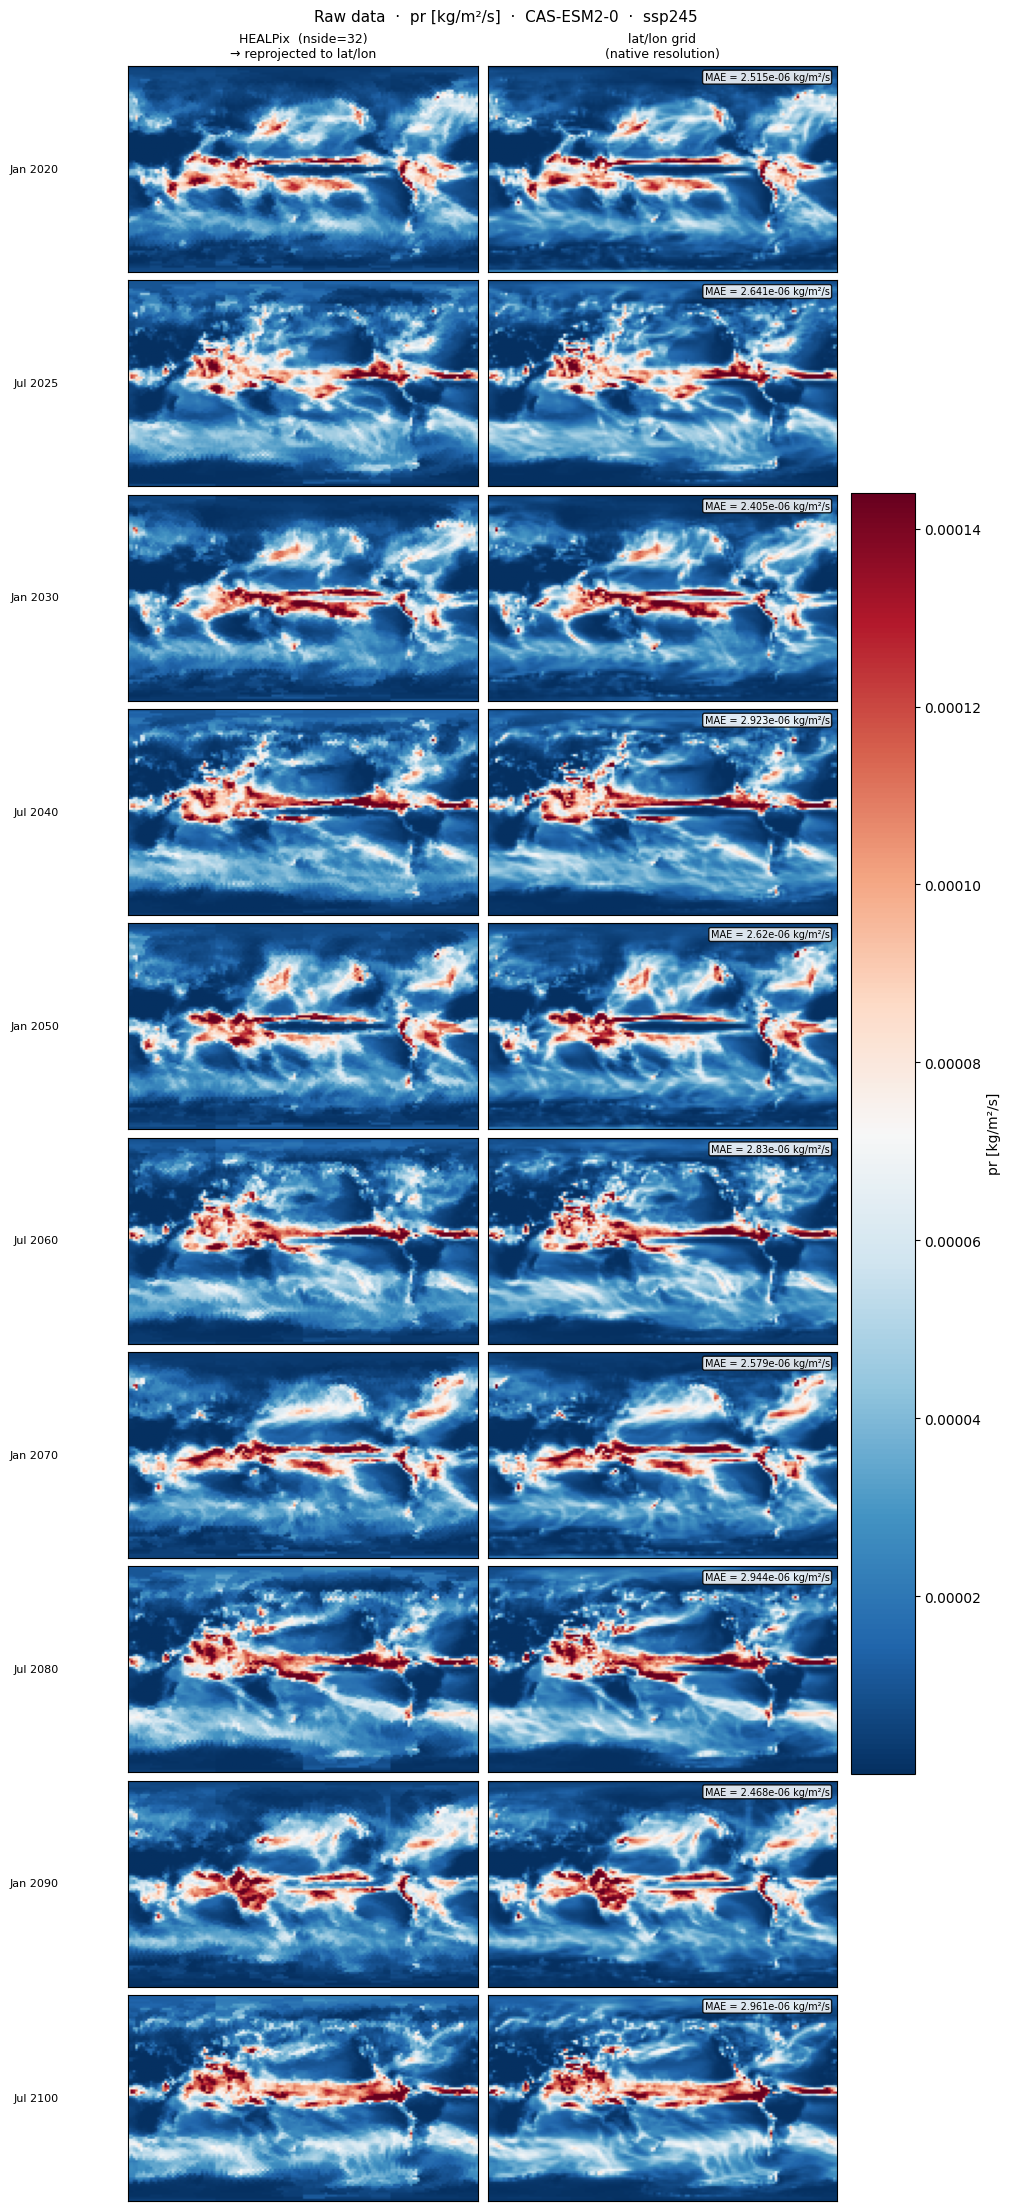

In [12]:
norm  = make_norm(vmin, vmax, LOG_SCALE)
n_ts  = len(TIMESTEPS)
scale_tag = "  [log]" if LOG_SCALE else ""

fig, axes = plt.subplots(
    n_ts, 2,
    figsize=(10, 2.2 * n_ts),
    constrained_layout=True,
)
if n_ts == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    f"Raw data  ·  {VAR_NAME} [{unit}]{scale_tag}  ·  {CLIMATE_MODEL}  ·  ssp245",
    fontsize=11,
)
axes[0, 0].set_title(f"HEALPix  (nside={NSIDE})\n→ reprojected to lat/lon", fontsize=9)
axes[0, 1].set_title("lat/lon grid\n(native resolution)",                    fontsize=9)

im = None
for ri, (hp_arr, nohp_arr, lbl) in enumerate(zip(hp_arrays, nohp_arrays, labels)):
    ax_hp   = axes[ri, 0]
    ax_nohp = axes[ri, 1]

    im = ax_hp.imshow(hp_arr,    origin="lower", cmap=CMAP, norm=norm, aspect="auto")
    ax_nohp.imshow(nohp_arr, origin="lower", cmap=CMAP, norm=norm, aspect="auto")

    for ax in (ax_hp, ax_nohp):
        ax.set_xticks([])
        ax.set_yticks([])

    ax_hp.set_ylabel(lbl, fontsize=8, rotation=0, ha="right", va="center", labelpad=50)

    # Mean absolute difference (HP reprojected vs no-HP) in top-right of no-HP panel
    mae = float(np.mean(np.abs(hp_arr - nohp_arr)))
    ax_nohp.text(
        0.98, 0.97, f"MAE = {mae:.4g} {unit}",
        transform=ax_nohp.transAxes, fontsize=7, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85),
    )

if im is not None:
    fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02, label=f"{VAR_NAME} [{unit}]")

plt.show()

## Difference map: HP − no-HP

Signed difference (HP reprojected minus no-HP) for all 10 timesteps.  
Diverging colourmap centred at zero — positive = HP higher, negative = no-HP higher.

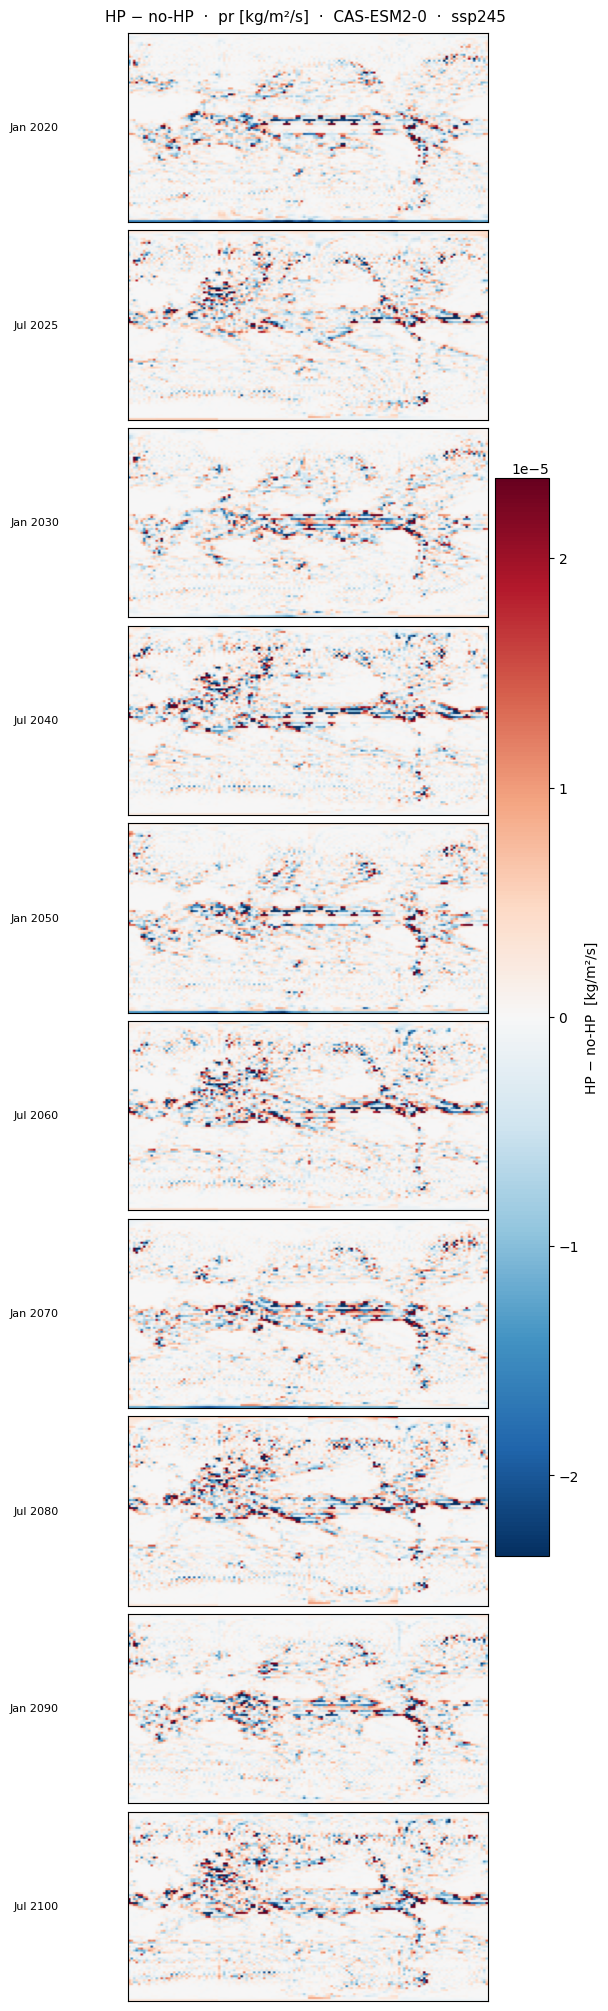

In [13]:
diffs    = [hp - nohp for hp, nohp in zip(hp_arrays, nohp_arrays)]
diff_abs = float(np.nanpercentile(np.abs(np.stack(diffs)), 99))
diff_norm = mcolors.Normalize(vmin=-diff_abs, vmax=diff_abs)

fig_d, axes_d = plt.subplots(
    n_ts, 1,
    figsize=(6, 2.0 * n_ts),
    constrained_layout=True,
)
if n_ts == 1:
    axes_d = [axes_d]

fig_d.suptitle(
    f"HP − no-HP  ·  {VAR_NAME} [{unit}]  ·  {CLIMATE_MODEL}  ·  ssp245",
    fontsize=11,
)

im_d = None
for ri, (diff, lbl) in enumerate(zip(diffs, labels)):
    ax = axes_d[ri]
    im_d = ax.imshow(diff, origin="lower", cmap="RdBu_r", norm=diff_norm, aspect="auto")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(lbl, fontsize=8, rotation=0, ha="right", va="center", labelpad=50)

if im_d is not None:
    fig_d.colorbar(im_d, ax=axes_d, shrink=0.6, pad=0.02,
                   label=f"HP − no-HP  [{unit}]")

plt.show()